# Setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import json
import re
import datetime
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt

In [3]:
SAVE_DIR = '/content/drive/MyDrive/dates_generator'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/weights', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/data', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/outputs', exist_ok=True)

In [4]:
Data_Path='/content/drive/MyDrive/dates_generator/data/data.txt'
Example_Path='/content/drive/MyDrive/dates_generator/data/example_input.txt'

In [5]:
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Read data + parsing

In [7]:
PAD = "<PAD>"
UNK = "<UNK>"

def read_lines(path: str) -> List[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f.readlines() if line.strip()]


def parse_training_line(line: str) -> Tuple[List[str], str]:
    """
    Example line:
    [WED] [JAN] [False] [180] 1-1-1800

    Returns:
    conditions = ["[WED]", "[JAN]", "[False]", "[180]"]
    date = "1-1-1800"
    """
    parts = line.split()
    conditions = parts[:4]
    date = parts[4]
    return conditions, date


def parse_input_line(line: str) -> List[str]:
    """
    [WED] [JAN] [False] [180]
    """
    return line.split()[:4]


def normalize_date(date_str: str) -> str:
    """
    1-1-1800-> 01-01-1800
    23-9-1892-> 23-09-1892
    """
    d, m, y = date_str.split("-")
    return f"{int(d):02d}-{int(m):02d}-{int(y):04d}"


def denormalize_date(date_str: str) -> str:
    """
    01-01-1800 -> 1-1-1800
    """
    try:
        d, m, y = date_str.split("-")
        return f"{int(d)}-{int(m)}-{int(y)}"
    except:
        return date_str



In [8]:
data_lines = read_lines(Data_Path)
example_lines = read_lines(Example_Path)

conditions_list = []
dates_list = []

for line in data_lines:
    cond, date = parse_training_line(line)
    conditions_list.append(cond)
    dates_list.append(normalize_date(date))

example_conditions_list = [parse_input_line(line) for line in example_lines]

print("Number of training lines:", len(data_lines))
print("Number of example input lines:", len(example_lines))

print("\nFirst 5 training examples:")
for i in range(5):
    print(conditions_list[i], dates_list[i])

print("\nFirst 5 example inputs:")
for i in range(5):
    print(example_conditions_list[i])

Number of training lines: 146462
Number of example input lines: 1465

First 5 training examples:
['[WED]', '[JAN]', '[False]', '[180]'] 01-01-1800
['[THU]', '[JAN]', '[False]', '[180]'] 01-01-1801
['[FRI]', '[JAN]', '[False]', '[180]'] 01-01-1802
['[SAT]', '[JAN]', '[False]', '[180]'] 01-01-1803
['[SUN]', '[JAN]', '[True]', '[180]'] 01-01-1804

First 5 example inputs:
['[WED]', '[JAN]', '[False]', '[180]']
['[MON]', '[JAN]', '[False]', '[190]']
['[SAT]', '[JAN]', '[True]', '[200]']
['[FRI]', '[JAN]', '[False]', '[210]']
['[WED]', '[JAN]', '[False]', '[220]']


# Calendar dictionaries + validation functions

In [9]:
MONTH_TO_NUM = {
    "[JAN]": 1, "[FEB]": 2, "[MAR]": 3, "[APR]": 4,
    "[MAY]": 5, "[JUN]": 6, "[JUL]": 7, "[AUG]": 8,
    "[SEP]": 9, "[OCT]": 10, "[NOV]": 11, "[DEC]": 12,
}

NUM_TO_MONTH = {v: k for k, v in MONTH_TO_NUM.items()}

DAY_TO_NUM = {
    "[MON]": 0, "[TUE]": 1, "[WED]": 2, "[THU]": 3,
    "[FRI]": 4, "[SAT]": 5, "[SUN]": 6,
}

NUM_TO_DAY = {v: k for k, v in DAY_TO_NUM.items()}


def is_leap_year(year: int) -> bool:
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)


def parse_generated_date(date_str: str):
    """
    Returns datetime.date if the date is valid.
    Otherwise returns None.
    Accepts:
    1-1-1800
    01-01-1800
    """
    match = re.fullmatch(r"\d{1,2}-\d{1,2}-\d{4}", date_str)

    if match is None:
        return None

    try:
        d, m, y = map(int, date_str.split("-"))
        return datetime.date(y, m, d)
    except:
        return None


def validate_date_against_conditions(date_str: str, conditions: List[str]) -> Dict[str, bool]:
    """
    conditions = ["[WED]", "[JAN]", "[False]", "[180]"]

    Checks:
    - valid date format
    - weekday match
    - month match
    - leap-year match
    - decade match
    """
    result = {
        "valid_format": False,
        "day_match": False,
        "month_match": False,
        "leap_match": False,
        "decade_match": False,
        "all_match": False,
    }

    dt = parse_generated_date(date_str)

    if dt is None:
        return result

    result["valid_format"] = True

    day_cond, month_cond, leap_cond, decade_cond = conditions

    result["day_match"] = dt.weekday() == DAY_TO_NUM[day_cond]

    result["month_match"] = dt.month == MONTH_TO_NUM[month_cond]

    expected_leap = True if leap_cond == "[True]" else False
    result["leap_match"] = is_leap_year(dt.year) == expected_leap

    decade_prefix = int(decade_cond.replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10
    end_year = start_year + 9

    result["decade_match"] = start_year <= dt.year <= end_year

    result["all_match"] = (
        result["valid_format"]
        and result["day_match"]
        and result["month_match"]
        and result["leap_match"]
        and result["decade_match"]
    )

    return result


In [10]:
sample_conditions = ["[WED]", "[JAN]", "[False]", "[180]"]
sample_date = "1-1-1800"

print("Sample conditions:", sample_conditions)
print("Sample date:", sample_date)
print(validate_date_against_conditions(sample_date, sample_conditions))

wrong_date = "2-1-1800"
print("\nWrong date test:", wrong_date)
print(validate_date_against_conditions(wrong_date, sample_conditions))

Sample conditions: ['[WED]', '[JAN]', '[False]', '[180]']
Sample date: 1-1-1800
{'valid_format': True, 'day_match': True, 'month_match': True, 'leap_match': True, 'decade_match': True, 'all_match': True}

Wrong date test: 2-1-1800
{'valid_format': True, 'day_match': False, 'month_match': True, 'leap_match': True, 'decade_match': True, 'all_match': False}


# Build feature vocabularies + train/val/test split

In [11]:
unique_conditions = []
seen = set()

for cond in conditions_list:
    key = tuple(cond)
    if key not in seen:
        seen.add(key)
        unique_conditions.append(cond)

print("Unique condition inputs:", len(unique_conditions))


Unique condition inputs: 6804


In [12]:
random.shuffle(unique_conditions)

n_total = len(unique_conditions)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_conditions = unique_conditions[:n_train]
val_conditions = unique_conditions[n_train:n_train + n_val]
test_conditions = unique_conditions[n_train + n_val:]

print("Train condition count:", len(train_conditions))
print("Val condition count:", len(val_conditions))
print("Test condition count:", len(test_conditions))

Train condition count: 5443
Val condition count: 680
Test condition count: 681


In [13]:
REQ_WEEKDAY_SIZE = 7
REQ_MONTH_SIZE = 12
REQ_LEAP_SIZE = 2
REQ_DECADE_SIZE = 41

CAND_WEEKDAY_SIZE = 7
CAND_MONTH_SIZE = 12
CAND_LEAP_SIZE = 2
CAND_DECADE_SIZE = 41
CAND_DAY_SIZE = 31
CAND_YEAR_OFFSET_SIZE =


In [33]:
def condition_tokens_to_feature_ids(condition_tokens: List[str]) -> List[int]:
    """
    Convert required condition tokens to feature IDs:
    [required_weekday, required_month, required_leap, required_decade]
    """
    day_cond, month_cond, leap_cond, decade_cond = condition_tokens

    required_weekday = DAY_TO_NUM[day_cond]
    required_month = MONTH_TO_NUM[month_cond] - 1
    required_leap = 1 if leap_cond == "[True]" else 0

    decade_prefix = int(decade_cond.replace("[", "").replace("]", ""))
    required_decade = decade_prefix - 180

    return [
        required_weekday,
        required_month,
        required_leap,
        required_decade,
    ]



In [34]:
sample_cond = ["[SUN]", "[JUL]", "[False]", "[196]"]
sample_date = "12-7-1965"

print("\nSample condition:", sample_cond)
print("Required feature ids:", condition_tokens_to_feature_ids(sample_cond))

print("Candidate date:", sample_date)
print("Validation:", validate_date_against_conditions(sample_date, sample_cond))


Sample condition: ['[SUN]', '[JUL]', '[False]', '[196]']
Required feature ids: [6, 6, 0, 16]
Candidate date: 12-7-1965
Validation: {'valid_format': True, 'day_match': False, 'month_match': True, 'leap_match': True, 'decade_match': True, 'all_match': False}


In [35]:
GRID_YEARS = 10
GRID_DAYS = 31
GRID_SIZE = GRID_YEARS * GRID_DAYS


def grid_index(year_offset: int, day: int) -> int:
    """
    Convert year_offset and day to grid index.

    year_offset: 0..9
    day: 1..31
    """
    return year_offset * GRID_DAYS + (day - 1)


def index_to_year_offset_day(index: int):
    """
    Convert grid index back to:
    year_offset: 0..9
    day: 1..31
    """
    year_offset = index // GRID_DAYS
    day = (index % GRID_DAYS) + 1
    return year_offset, day


def build_grid_label(condition_tokens: List[str]) -> torch.Tensor:
    """
    Build multi-hot target vector of length 310.

    label[i] = 1 if the date represented by grid cell i satisfies:
    weekday + month + leap + decade
    """
    labels = torch.zeros(GRID_SIZE, dtype=torch.float)

    day_cond, month_cond, leap_cond, decade_cond = condition_tokens

    target_month = MONTH_TO_NUM[month_cond]

    decade_prefix = int(decade_cond.replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10

    for year_offset in range(GRID_YEARS):
        year = start_year + year_offset

        for day in range(1, GRID_DAYS + 1):
            try:
                dt = datetime.date(year, target_month, day)
            except ValueError:
                continue

            date_str = f"{dt.day}-{dt.month}-{dt.year}"

            result = validate_date_against_conditions(date_str, condition_tokens)

            if result["all_match"]:
                idx = grid_index(year_offset, day)
                labels[idx] = 1.0

    return labels


def decode_grid_index(index: int, condition_tokens: List[str]) -> str:
    """
    Convert predicted grid index to date string.
    """
    year_offset, day = index_to_year_offset_day(index)

    month = MONTH_TO_NUM[condition_tokens[1]]

    decade_prefix = int(condition_tokens[3].replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10

    year = start_year + year_offset

    return f"{day}-{month}-{year}"


In [36]:
sample_cond = ["[WED]", "[JAN]", "[False]", "[180]"]
sample_label = build_grid_label(sample_cond)

print("Sample condition:", sample_cond)
print("Grid size:", GRID_SIZE)
print("Number of valid answers:", int(sample_label.sum().item()))

valid_indices = torch.where(sample_label == 1)[0].tolist()

print("First 10 valid indices:", valid_indices[:10])

print("\nFirst 5 valid decoded dates:")
for idx in valid_indices[:5]:
    print(idx, "->", decode_grid_index(idx, sample_cond))

Sample condition: ['[WED]', '[JAN]', '[False]', '[180]']
Grid size: 310
Number of valid answers: 35
First 10 valid indices: [0, 7, 14, 21, 28, 37, 44, 51, 58, 67]

First 5 valid decoded dates:
0 -> 1-1-1800
7 -> 8-1-1800
14 -> 15-1-1800
21 -> 22-1-1800
28 -> 29-1-1800


In [37]:
class GridDatesDataset(Dataset):
    def __init__(self, condition_inputs: List[List[str]]):
        self.condition_inputs = condition_inputs

    def __len__(self):
        return len(self.condition_inputs)

    def __getitem__(self, idx):
        cond_tokens = self.condition_inputs[idx]

        condition_features = torch.tensor(
            condition_tokens_to_feature_ids(cond_tokens),
            dtype=torch.long
        )

        labels = build_grid_label(cond_tokens)

        return {
            "condition_features": condition_features,
            "labels": labels,
        }


grid_train_dataset = GridDatesDataset(train_conditions)
grid_val_dataset = GridDatesDataset(val_conditions)
grid_test_dataset = GridDatesDataset(test_conditions)

GRID_BATCH_SIZE = 128

grid_train_loader = DataLoader(
    grid_train_dataset,
    batch_size=GRID_BATCH_SIZE,
    shuffle=True,
)

grid_val_loader = DataLoader(
    grid_val_dataset,
    batch_size=GRID_BATCH_SIZE,
    shuffle=False,
)

grid_test_loader = DataLoader(
    grid_test_dataset,
    batch_size=GRID_BATCH_SIZE,
    shuffle=False,
)

print("Grid train samples:", len(grid_train_dataset))
print("Grid val samples:", len(grid_val_dataset))
print("Grid test samples:", len(grid_test_dataset))

batch = next(iter(grid_train_loader))

print("\nBatch shapes:")
print("condition_features:", batch["condition_features"].shape)
print("labels:", batch["labels"].shape)

print("\nExample label positives in first batch item:")
positive_indices = torch.where(batch["labels"][0] == 1)[0].tolist()
print("Number of positives:", len(positive_indices))
print("First positive indices:", positive_indices[:10])

Grid train samples: 5443
Grid val samples: 680
Grid test samples: 681

Batch shapes:
condition_features: torch.Size([128, 4])
labels: torch.Size([128, 310])

Example label positives in first batch item:
Number of positives: 34
First positive indices: [0, 7, 14, 21, 28, 37, 44, 51, 58, 96]


In [38]:

def decode_grid_prediction(logits: torch.Tensor, condition_tokens: List[str]) -> str:
    """
    logits: [310]
    Chooses the highest-scoring real calendar date.
    It avoids impossible dates like 31-Feb.
    """
    scores = logits.detach().cpu()

    sorted_indices = torch.argsort(scores, descending=True).tolist()

    month = MONTH_TO_NUM[condition_tokens[1]]

    decade_prefix = int(condition_tokens[3].replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10

    for idx in sorted_indices:
        year_offset, day = index_to_year_offset_day(idx)
        year = start_year + year_offset

        try:
            datetime.date(year, month, day)
            return f"{day}-{month}-{year}"
        except ValueError:
            continue

    return "1-1-1800"


def evaluate_grid_generation(model, condition_inputs: List[List[str]], n_samples=300):
    model.eval()

    selected = random.sample(
        condition_inputs,
        min(n_samples, len(condition_inputs))
    )

    total = 0
    valid_format = 0
    day_match = 0
    month_match = 0
    leap_match = 0
    decade_match = 0
    all_match = 0

    with torch.no_grad():
        for cond_tokens in selected:
            cond_features = torch.tensor(
                [condition_tokens_to_feature_ids(cond_tokens)],
                dtype=torch.long
            ).to(DEVICE)

            logits = model(cond_features)[0]

            pred_date = decode_grid_prediction(logits, cond_tokens)

            result = validate_date_against_conditions(pred_date, cond_tokens)

            total += 1
            valid_format += int(result["valid_format"])
            day_match += int(result["day_match"])
            month_match += int(result["month_match"])
            leap_match += int(result["leap_match"])
            decade_match += int(result["decade_match"])
            all_match += int(result["all_match"])

    return {
        "valid_format": valid_format / total,
        "day_match": day_match / total,
        "month_match": month_match / total,
        "leap_match": leap_match / total,
        "decade_match": decade_match / total,
        "all_match": all_match / total,
    }


def show_grid_predictions(model, condition_inputs: List[List[str]], n=10):
    model.eval()

    selected = random.sample(
        condition_inputs,
        min(n, len(condition_inputs))
    )

    with torch.no_grad():
        for cond_tokens in selected:
            cond_features = torch.tensor(
                [condition_tokens_to_feature_ids(cond_tokens)],
                dtype=torch.long
            ).to(DEVICE)

            logits = model(cond_features)[0]
            pred_date = decode_grid_prediction(logits, cond_tokens)

            label = build_grid_label(cond_tokens)
            positive_indices = torch.where(label == 1)[0].tolist()

            valid_examples = [
                decode_grid_index(idx, cond_tokens)
                for idx in positive_indices[:5]
            ]

            result = validate_date_against_conditions(pred_date, cond_tokens)

            print("Conditions:", " ".join(cond_tokens))
            print("Predicted date:", pred_date)
            print("Some valid examples:", valid_examples)
            print("All conditions satisfied:", result["all_match"])
            print("-" * 60)


def compute_grid_pos_weight(dataset):
    """
    Compute pos_weight for BCEWithLogitsLoss because grid labels are imbalanced:
    many zeros, fewer valid dates.
    """
    positives = 0
    negatives = 0

    for i in range(len(dataset)):
        labels = dataset[i]["labels"]
        positives += int(labels.sum().item())
        negatives += int(labels.numel() - labels.sum().item())

    pos_weight = negatives / max(positives, 1)

    print("Grid positives:", positives)
    print("Grid negatives:", negatives)
    print("Grid pos_weight:", pos_weight)

    return torch.tensor([pos_weight], dtype=torch.float).to(DEVICE)


def train_grid_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0

    for batch in loader:
        condition_features = batch["condition_features"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(condition_features)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_grid_loss(model, loader, criterion):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            condition_features = batch["condition_features"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(condition_features)

            loss = criterion(logits, labels)

            total_loss += loss.item()

    return total_loss / len(loader)


grid_pos_weight = compute_grid_pos_weight(grid_train_dataset)

grid_criterion = nn.BCEWithLogitsLoss(
    pos_weight=grid_pos_weight
)

Grid positives: 119163
Grid negatives: 1568167
Grid pos_weight: 13.15984827505182


# Model 1 : AE

In [39]:
class AEGridGenerator(nn.Module):
    def __init__(
        self,
        d_model: int = 32,
        hidden_dim: int = 128,
        latent_dim: int = 64,
        grid_size: int = GRID_SIZE,
    ):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])

        x = torch.cat([weekday, month, leap, decade], dim=1)
        return x

    def forward(self, condition_features):
        x = self.embed_conditions(condition_features)
        z = self.encoder(x)
        logits = self.decoder(z)

        return logits

In [40]:
ae_grid_model = AEGridGenerator(
    d_model=32,
    hidden_dim=128,
    latent_dim=64,
    grid_size=GRID_SIZE,
).to(DEVICE)

ae_grid_optimizer = torch.optim.Adam(
    ae_grid_model.parameters(),
    lr=1e-3
)

AE_GRID_EPOCHS = 30

ae_grid_train_losses = []
ae_grid_val_losses = []

best_ae_grid_val_loss = float("inf")
best_ae_grid_path = f"{SAVE_DIR}/weights/ae_grid_generator.pt"

for epoch in range(1, AE_GRID_EPOCHS + 1):
    train_loss = train_grid_one_epoch(
        ae_grid_model,
        grid_train_loader,
        ae_grid_optimizer,
        grid_criterion
    )

    val_loss = evaluate_grid_loss(
        ae_grid_model,
        grid_val_loader,
        grid_criterion
    )

    ae_grid_train_losses.append(train_loss)
    ae_grid_val_losses.append(val_loss)

    if val_loss < best_ae_grid_val_loss:
        best_ae_grid_val_loss = val_loss
        torch.save(ae_grid_model.state_dict(), best_ae_grid_path)

    if epoch % 5 == 0 or epoch == 1:
        quality = evaluate_grid_generation(
            ae_grid_model,
            val_conditions,
            n_samples=300
        )

        print(
            f"Epoch [{epoch}/{AE_GRID_EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Generation All Match: {quality['all_match']:.4f}"
        )

print("Best AE Grid model saved to:", best_ae_grid_path)

Epoch [1/30] Train Loss: 1.2052 | Val Loss: 1.0743 | Generation All Match: 0.0800
Epoch [5/30] Train Loss: 0.8695 | Val Loss: 0.8585 | Generation All Match: 0.0933
Epoch [10/30] Train Loss: 0.8516 | Val Loss: 0.8461 | Generation All Match: 0.1700
Epoch [15/30] Train Loss: 0.8487 | Val Loss: 0.8448 | Generation All Match: 0.1067
Epoch [20/30] Train Loss: 0.8457 | Val Loss: 0.8464 | Generation All Match: 0.1000
Epoch [25/30] Train Loss: 0.8392 | Val Loss: 0.8492 | Generation All Match: 0.1400
Epoch [30/30] Train Loss: 0.6879 | Val Loss: 0.7122 | Generation All Match: 0.2633
Best AE Grid model saved to: /content/drive/MyDrive/dates_generator/weights/ae_grid_generator.pt


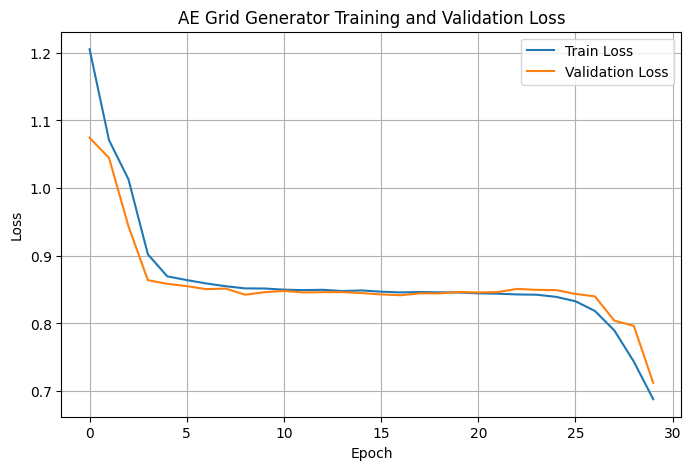

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(ae_grid_train_losses, label="Train Loss")
plt.plot(ae_grid_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AE Grid Generator Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
ae_grid_model.load_state_dict(
    torch.load(best_ae_grid_path, map_location=DEVICE)
)
ae_grid_model.eval()

print("AE Grid Generation Test Quality:")
ae_grid_quality = evaluate_grid_generation(
    ae_grid_model,
    test_conditions,
    n_samples=300
)

for key, value in ae_grid_quality.items():
    print(f"{key}: {value:.4f}")

print("\nSample AE Grid predictions:")
show_grid_predictions(ae_grid_model, test_conditions, n=10)

AE Grid Generation Test Quality:
valid_format: 1.0000
day_match: 0.3233
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 0.3233

Sample AE Grid predictions:
Conditions: [TUE] [MAY] [False] [181]
Predicted date: 8-5-1814
Some valid examples: ['1-5-1810', '8-5-1810', '15-5-1810', '22-5-1810', '29-5-1810']
All conditions satisfied: False
------------------------------------------------------------
Conditions: [THU] [JAN] [True] [213]
Predicted date: 13-1-2132
Some valid examples: ['3-1-2132', '10-1-2132', '17-1-2132', '24-1-2132', '31-1-2132']
All conditions satisfied: False
------------------------------------------------------------
Conditions: [WED] [AUG] [True] [206]
Predicted date: 14-8-2060
Some valid examples: ['4-8-2060', '11-8-2060', '18-8-2060', '25-8-2060', '6-8-2064']
All conditions satisfied: False
------------------------------------------------------------
Conditions: [MON] [JAN] [False] [213]
Predicted date: 31-1-2135
Some valid examples: ['2-1-2130',

In [43]:
EXTRA_AE_GRID_EPOCHS = 30

start_epoch = AE_GRID_EPOCHS + 1
end_epoch = AE_GRID_EPOCHS + EXTRA_AE_GRID_EPOCHS

for epoch in range(start_epoch, end_epoch + 1):
    train_loss = train_grid_one_epoch(
        ae_grid_model,
        grid_train_loader,
        ae_grid_optimizer,
        grid_criterion
    )

    val_loss = evaluate_grid_loss(
        ae_grid_model,
        grid_val_loader,
        grid_criterion
    )

    ae_grid_train_losses.append(train_loss)
    ae_grid_val_losses.append(val_loss)

    if val_loss < best_ae_grid_val_loss:
        best_ae_grid_val_loss = val_loss
        torch.save(ae_grid_model.state_dict(), best_ae_grid_path)

    if epoch % 5 == 0 or epoch == start_epoch:
        quality = evaluate_grid_generation(
            ae_grid_model,
            val_conditions,
            n_samples=300
        )

        print(
            f"Epoch [{epoch}/{end_epoch}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Generation All Match: {quality['all_match']:.4f}"
        )

AE_GRID_EPOCHS = end_epoch

print("Updated best AE Grid model saved to:", best_ae_grid_path)

Epoch [31/60] Train Loss: 0.6167 | Val Loss: 0.6265 | Generation All Match: 0.3300
Epoch [35/60] Train Loss: 0.3570 | Val Loss: 0.3854 | Generation All Match: 0.6267
Epoch [40/60] Train Loss: 0.1365 | Val Loss: 0.1737 | Generation All Match: 0.8300
Epoch [45/60] Train Loss: 0.0530 | Val Loss: 0.1000 | Generation All Match: 0.9233
Epoch [50/60] Train Loss: 0.0262 | Val Loss: 0.0700 | Generation All Match: 0.9467
Epoch [55/60] Train Loss: 0.0159 | Val Loss: 0.0610 | Generation All Match: 0.9733
Epoch [60/60] Train Loss: 0.0105 | Val Loss: 0.0518 | Generation All Match: 0.9700
Updated best AE Grid model saved to: /content/drive/MyDrive/dates_generator/weights/ae_grid_generator.pt


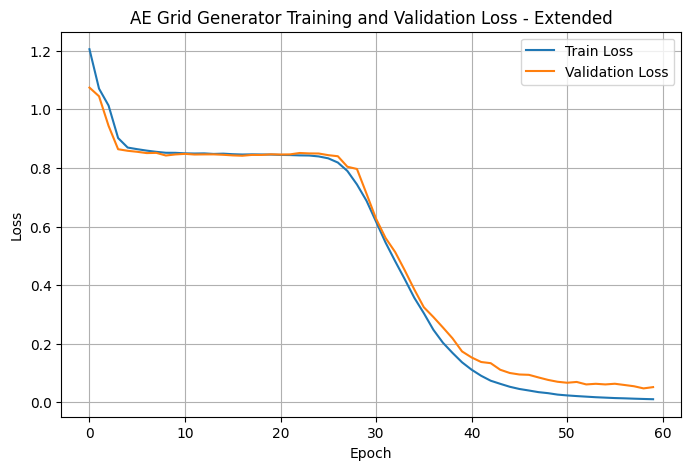

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(ae_grid_train_losses, label="Train Loss")
plt.plot(ae_grid_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AE Grid Generator Training and Validation Loss - Extended")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
ae_grid_model.load_state_dict(
    torch.load(best_ae_grid_path, map_location=DEVICE)
)
ae_grid_model.eval()

print("AE Grid Generation Test Quality After Extra Training:")
ae_grid_quality = evaluate_grid_generation(
    ae_grid_model,
    test_conditions,
    n_samples=300
)

for key, value in ae_grid_quality.items():
    print(f"{key}: {value:.4f}")

print("\nSample AE Grid predictions after extra training:")
show_grid_predictions(ae_grid_model, test_conditions, n=10)

AE Grid Generation Test Quality After Extra Training:
valid_format: 1.0000
day_match: 0.9767
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 0.9767

Sample AE Grid predictions after extra training:
Conditions: [TUE] [APR] [False] [206]
Predicted date: 14-4-2065
Some valid examples: ['5-4-2061', '12-4-2061', '19-4-2061', '26-4-2061', '4-4-2062']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [WED] [MAY] [False] [204]
Predicted date: 28-5-2042
Some valid examples: ['1-5-2041', '8-5-2041', '15-5-2041', '22-5-2041', '29-5-2041']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [TUE] [DEC] [True] [215]
Predicted date: 14-12-2156
Some valid examples: ['5-12-2152', '12-12-2152', '19-12-2152', '26-12-2152', '7-12-2156']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [MON] [DEC] [True] [215]
Predicted date

# Model 2 : GAN

In [46]:
class GANGridGenerator(nn.Module):
    def __init__(
        self,
        noise_dim: int = 32,
        d_model: int = 32,
        hidden_dim: int = 128,
        grid_size: int = GRID_SIZE,
    ):
        super().__init__()

        self.noise_dim = noise_dim

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model + noise_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])

        return torch.cat([weekday, month, leap, decade], dim=1)

    def forward(self, condition_features, noise):
        cond_emb = self.embed_conditions(condition_features)
        x = torch.cat([cond_emb, noise], dim=1)
        logits = self.net(x)

        return logits

    def generate(self, condition_features):
        self.eval()

        batch_size = condition_features.size(0)
        noise = torch.randn(batch_size, self.noise_dim).to(condition_features.device)

        with torch.no_grad():
            logits = self.forward(condition_features, noise)

        return logits


class GANGridDiscriminator(nn.Module):
    def __init__(
        self,
        d_model: int = 32,
        hidden_dim: int = 128,
        grid_size: int = GRID_SIZE,
    ):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        cond_dim = 4 * d_model

        self.net = nn.Sequential(
            nn.Linear(cond_dim + grid_size, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])

        return torch.cat([weekday, month, leap, decade], dim=1)

    def forward(self, condition_features, grid_probs):
        cond_emb = self.embed_conditions(condition_features)

        x = torch.cat([cond_emb, grid_probs], dim=1)

        validity_logit = self.net(x)

        return validity_logit

In [47]:
def train_gan_grid_one_epoch(
    generator_model,
    discriminator_model,
    loader,
    g_optimizer,
    d_optimizer,
    adv_criterion,
    grid_criterion,
    noise_dim: int = 32,
    supervised_weight: float = 1.0,
    adv_weight: float = 0.1,
):
    generator_model.train()
    discriminator_model.train()

    total_g_loss = 0.0
    total_d_loss = 0.0
    total_supervised_g_loss = 0.0
    total_adv_g_loss = 0.0

    for batch in loader:
        condition_features = batch["condition_features"].to(DEVICE)
        real_labels_grid = batch["labels"].to(DEVICE)

        batch_size = condition_features.size(0)

        real_valid_labels = torch.ones(batch_size, 1).to(DEVICE) * 0.9
        fake_valid_labels = torch.zeros(batch_size, 1).to(DEVICE)

        d_optimizer.zero_grad()

        real_grid_probs = real_labels_grid.float()

        real_logits = discriminator_model(
            condition_features,
            real_grid_probs
        )

        d_real_loss = adv_criterion(real_logits, real_valid_labels)

        noise = torch.randn(batch_size, noise_dim).to(DEVICE)

        fake_grid_logits = generator_model(condition_features, noise)
        fake_grid_probs = torch.sigmoid(fake_grid_logits)

        fake_logits = discriminator_model(
            condition_features,
            fake_grid_probs.detach()
        )

        d_fake_loss = adv_criterion(fake_logits, fake_valid_labels)

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()
        d_optimizer.step()

        g_optimizer.zero_grad()

        noise = torch.randn(batch_size, noise_dim).to(DEVICE)

        fake_grid_logits = generator_model(condition_features, noise)
        fake_grid_probs = torch.sigmoid(fake_grid_logits)

        supervised_g_loss = grid_criterion(
            fake_grid_logits,
            real_labels_grid
        )

        fake_logits_for_g = discriminator_model(
            condition_features,
            fake_grid_probs
        )

        adv_g_loss = adv_criterion(fake_logits_for_g, real_valid_labels)

        g_loss = supervised_weight * supervised_g_loss + adv_weight * adv_g_loss

        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator_model.parameters(), max_norm=1.0)
        g_optimizer.step()

        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()
        total_supervised_g_loss += supervised_g_loss.item()
        total_adv_g_loss += adv_g_loss.item()

    return {
        "g_loss": total_g_loss / len(loader),
        "d_loss": total_d_loss / len(loader),
        "supervised_g_loss": total_supervised_g_loss / len(loader),
        "adv_g_loss": total_adv_g_loss / len(loader),
    }


def evaluate_gan_grid_loss(generator_model, loader, criterion, noise_dim: int = 32):
    generator_model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            condition_features = batch["condition_features"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            batch_size = condition_features.size(0)

            noise = torch.randn(batch_size, noise_dim).to(DEVICE)

            logits = generator_model(condition_features, noise)

            loss = criterion(logits, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [48]:
NOISE_DIM = 32

gan_grid_generator = GANGridGenerator(
    noise_dim=NOISE_DIM,
    d_model=32,
    hidden_dim=128,
    grid_size=GRID_SIZE,
).to(DEVICE)

gan_grid_discriminator = GANGridDiscriminator(
    d_model=32,
    hidden_dim=128,
    grid_size=GRID_SIZE,
).to(DEVICE)

gan_grid_g_optimizer = torch.optim.Adam(
    gan_grid_generator.parameters(),
    lr=1e-3
)

gan_grid_d_optimizer = torch.optim.Adam(
    gan_grid_discriminator.parameters(),
    lr=1e-3
)

gan_adv_criterion = nn.BCEWithLogitsLoss()

GAN_GRID_EPOCHS = 60

gan_grid_g_losses = []
gan_grid_d_losses = []
gan_grid_val_losses = []

best_gan_grid_val_loss = float("inf")
best_gan_grid_generator_path = f"{SAVE_DIR}/weights/gan_grid_generator.pt"
best_gan_grid_discriminator_path = f"{SAVE_DIR}/weights/gan_grid_discriminator.pt"

In [50]:
class GANGridEvalWrapper(nn.Module):
    def __init__(self, generator_model, noise_dim: int = 32):
        super().__init__()
        self.generator_model = generator_model
        self.noise_dim = noise_dim

    def forward(self, condition_features):
        batch_size = condition_features.size(0)
        noise = torch.randn(batch_size, self.noise_dim).to(condition_features.device)
        return self.generator_model(condition_features, noise)

In [51]:
for epoch in range(1, GAN_GRID_EPOCHS + 1):
    train_metrics = train_gan_grid_one_epoch(
        gan_grid_generator,
        gan_grid_discriminator,
        grid_train_loader,
        gan_grid_g_optimizer,
        gan_grid_d_optimizer,
        gan_adv_criterion,
        grid_criterion,
        noise_dim=NOISE_DIM,
        supervised_weight=1.0,
        adv_weight=0.1,
    )

    val_loss = evaluate_gan_grid_loss(
        gan_grid_generator,
        grid_val_loader,
        grid_criterion,
        noise_dim=NOISE_DIM
    )

    gan_grid_g_losses.append(train_metrics["g_loss"])
    gan_grid_d_losses.append(train_metrics["d_loss"])
    gan_grid_val_losses.append(val_loss)

    if val_loss < best_gan_grid_val_loss:
        best_gan_grid_val_loss = val_loss
        torch.save(gan_grid_generator.state_dict(), best_gan_grid_generator_path)
        torch.save(gan_grid_discriminator.state_dict(), best_gan_grid_discriminator_path)

    if epoch % 5 == 0 or epoch == 1:
        gan_eval_model = GANGridEvalWrapper(gan_grid_generator, noise_dim=NOISE_DIM).to(DEVICE)

        quality = evaluate_grid_generation(
          gan_eval_model,
          val_conditions,
          n_samples=300
          )

        print(
            f"Epoch [{epoch}/{GAN_GRID_EPOCHS}] "
            f"G Loss: {train_metrics['g_loss']:.4f} | "
            f"D Loss: {train_metrics['d_loss']:.4f} | "
            f"Sup G: {train_metrics['supervised_g_loss']:.4f} | "
            f"Adv G: {train_metrics['adv_g_loss']:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Generation All Match: {quality['all_match']:.4f}"
        )

print("Best GAN Grid generator saved to:", best_gan_grid_generator_path)
print("Best GAN Grid discriminator saved to:", best_gan_grid_discriminator_path)

Epoch [1/60] G Loss: 2.2288 | D Loss: 0.9078 | Sup G: 2.0433 | Adv G: 1.8558 | Val Loss: 2.1650 | Generation All Match: 0.1033
Epoch [5/60] G Loss: 2.2659 | D Loss: 0.3881 | Sup G: 1.8532 | Adv G: 4.1274 | Val Loss: 1.9042 | Generation All Match: 0.1500
Epoch [10/60] G Loss: 2.5713 | D Loss: 0.3839 | Sup G: 2.0799 | Adv G: 4.9139 | Val Loss: 2.0644 | Generation All Match: 0.1200
Epoch [15/60] G Loss: 2.6886 | D Loss: 0.3793 | Sup G: 2.1611 | Adv G: 5.2754 | Val Loss: 2.1675 | Generation All Match: 0.1267
Epoch [20/60] G Loss: 2.6487 | D Loss: 0.3644 | Sup G: 2.0333 | Adv G: 6.1542 | Val Loss: 2.0913 | Generation All Match: 0.1133
Epoch [25/60] G Loss: 2.7831 | D Loss: 0.3922 | Sup G: 2.2067 | Adv G: 5.7636 | Val Loss: 2.1786 | Generation All Match: 0.1333
Epoch [30/60] G Loss: 2.6542 | D Loss: 0.3758 | Sup G: 1.9167 | Adv G: 7.3747 | Val Loss: 2.0149 | Generation All Match: 0.1333
Epoch [35/60] G Loss: 2.7303 | D Loss: 0.3501 | Sup G: 1.9834 | Adv G: 7.4688 | Val Loss: 2.0359 | Generat

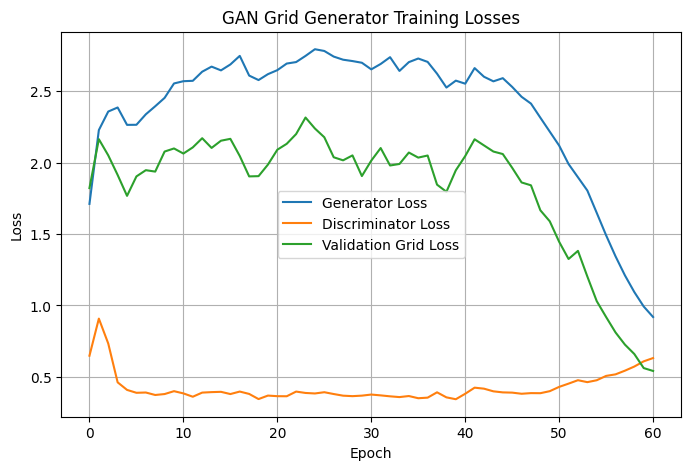

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(gan_grid_g_losses, label="Generator Loss")
plt.plot(gan_grid_d_losses, label="Discriminator Loss")
plt.plot(gan_grid_val_losses, label="Validation Grid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Grid Generator Training Losses")
plt.legend()
plt.grid(True)
plt.show()

In [54]:

gan_grid_generator.load_state_dict(
    torch.load(best_gan_grid_generator_path, map_location=DEVICE)
)
gan_grid_generator.eval()

gan_eval_model = GANGridEvalWrapper(
    gan_grid_generator,
    noise_dim=NOISE_DIM
).to(DEVICE)

print("GAN Grid Generation Test Quality:")
gan_grid_quality = evaluate_grid_generation(
    gan_eval_model,
    test_conditions,
    n_samples=300
)

for key, value in gan_grid_quality.items():
    print(f"{key}: {value:.4f}")

print("\nSample GAN Grid predictions:")
show_grid_predictions(
    gan_eval_model,
    test_conditions,
    n=10
)

GAN Grid Generation Test Quality:
valid_format: 1.0000
day_match: 0.6933
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 0.6933

Sample GAN Grid predictions:
Conditions: [THU] [SEP] [False] [198]
Predicted date: 16-9-1982
Some valid examples: ['3-9-1981', '10-9-1981', '17-9-1981', '24-9-1981', '2-9-1982']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [SUN] [FEB] [False] [212]
Predicted date: 23-2-2121
Some valid examples: ['2-2-2121', '9-2-2121', '16-2-2121', '23-2-2121', '1-2-2122']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [FRI] [JAN] [False] [183]
Predicted date: 28-1-1831
Some valid examples: ['1-1-1830', '8-1-1830', '15-1-1830', '22-1-1830', '29-1-1830']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [SAT] [OCT] [False] [199]
Predicted date: 22-10-1994
Some valid examples: ['6-10-1990

# Model 3 : CVAE

In [55]:
class CVAEGridGenerator(nn.Module):
    def __init__(
        self,
        d_model: int = 32,
        hidden_dim: int = 128,
        latent_dim: int = 64,
        grid_size: int = GRID_SIZE,
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.grid_size = grid_size

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])

        x = torch.cat([weekday, month, leap, decade], dim=1)
        return x

    def encode(self, condition_features):
        cond_emb = self.embed_conditions(condition_features)

        h = self.encoder(cond_emb)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar, cond_emb

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z, cond_emb):
        decoder_input = torch.cat([z, cond_emb], dim=1)
        logits = self.decoder(decoder_input)

        return logits

    def forward(self, condition_features):
        mu, logvar, cond_emb = self.encode(condition_features)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, cond_emb)

        return logits, mu, logvar

    def generate(self, condition_features, use_mean=True):
        self.eval()

        with torch.no_grad():
            mu, logvar, cond_emb = self.encode(condition_features)

            if use_mean:
                z = mu
            else:
                z = self.reparameterize(mu, logvar)

            logits = self.decode(z, cond_emb)

        return logits

In [56]:

def cvae_grid_loss_function(
    logits,
    labels,
    mu,
    logvar,
    grid_criterion,
    beta: float = 0.01,
):
    recon_loss = grid_criterion(logits, labels)

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


def train_cvae_grid_one_epoch(
    model,
    loader,
    optimizer,
    grid_criterion,
    beta: float,
):
    model.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for batch in loader:
        condition_features = batch["condition_features"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        logits, mu, logvar = model(condition_features)

        loss, recon_loss, kl_loss = cvae_grid_loss_function(
            logits,
            labels,
            mu,
            logvar,
            grid_criterion,
            beta=beta
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
    }


def evaluate_cvae_grid_loss(
    model,
    loader,
    grid_criterion,
    beta: float,
):
    model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():
        for batch in loader:
            condition_features = batch["condition_features"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits, mu, logvar = model(condition_features)

            loss, recon_loss, kl_loss = cvae_grid_loss_function(
                logits,
                labels,
                mu,
                logvar,
                grid_criterion,
                beta=beta
            )

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

    return {
        "loss": total_loss / len(loader),
        "recon": total_recon / len(loader),
        "kl": total_kl / len(loader),
    }


class CVAEGridEvalWrapper(nn.Module):

    def __init__(self, cvae_model, use_mean: bool = True):
        super().__init__()
        self.cvae_model = cvae_model
        self.use_mean = use_mean

    def forward(self, condition_features):
        return self.cvae_model.generate(condition_features, use_mean=self.use_mean)

cvae_grid_model = CVAEGridGenerator(
    d_model=32,
    hidden_dim=128,
    latent_dim=64,
    grid_size=GRID_SIZE,
).to(DEVICE)

cvae_grid_optimizer = torch.optim.Adam(
    cvae_grid_model.parameters(),
    lr=1e-3
)

CVAE_GRID_EPOCHS = 60

cvae_grid_train_losses = []
cvae_grid_val_losses = []
cvae_grid_kl_losses = []

best_cvae_grid_val_loss = float("inf")
best_cvae_grid_path = f"{SAVE_DIR}/weights/cvae_grid_generator.pt"


In [57]:
for epoch in range(1, CVAE_GRID_EPOCHS + 1):
    beta = min(0.01, epoch / CVAE_GRID_EPOCHS * 0.01)

    train_metrics = train_cvae_grid_one_epoch(
        cvae_grid_model,
        grid_train_loader,
        cvae_grid_optimizer,
        grid_criterion,
        beta=beta
    )

    val_metrics = evaluate_cvae_grid_loss(
        cvae_grid_model,
        grid_val_loader,
        grid_criterion,
        beta=beta
    )

    cvae_grid_train_losses.append(train_metrics["loss"])
    cvae_grid_val_losses.append(val_metrics["loss"])
    cvae_grid_kl_losses.append(train_metrics["kl"])

    if val_metrics["loss"] < best_cvae_grid_val_loss:
        best_cvae_grid_val_loss = val_metrics["loss"]
        torch.save(cvae_grid_model.state_dict(), best_cvae_grid_path)

    if epoch % 5 == 0 or epoch == 1:
        cvae_eval_model = CVAEGridEvalWrapper(
            cvae_grid_model,
            use_mean=True
        ).to(DEVICE)

        quality = evaluate_grid_generation(
            cvae_eval_model,
            val_conditions,
            n_samples=300
        )

        print(
            f"Epoch [{epoch}/{CVAE_GRID_EPOCHS}] "
            f"Beta: {beta:.5f} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Recon: {train_metrics['recon']:.4f} | "
            f"KL: {train_metrics['kl']:.4f} | "
            f"Generation All Match: {quality['all_match']:.4f}"
        )

print("Best CVAE Grid model saved to:", best_cvae_grid_path)


Epoch [1/60] Beta: 0.00017 | Train Loss: 1.1892 | Val Loss: 1.0658 | Recon: 1.1891 | KL: 0.7359 | Generation All Match: 0.0900
Epoch [5/60] Beta: 0.00083 | Train Loss: 0.8697 | Val Loss: 0.8641 | Recon: 0.8685 | KL: 1.5391 | Generation All Match: 0.1333
Epoch [10/60] Beta: 0.00167 | Train Loss: 0.8518 | Val Loss: 0.8452 | Recon: 0.8507 | KL: 0.6466 | Generation All Match: 0.1500
Epoch [15/60] Beta: 0.00250 | Train Loss: 0.8441 | Val Loss: 0.8528 | Recon: 0.8430 | KL: 0.4414 | Generation All Match: 0.0767
Epoch [20/60] Beta: 0.00333 | Train Loss: 0.6688 | Val Loss: 0.6809 | Recon: 0.6653 | KL: 1.0786 | Generation All Match: 0.2867
Epoch [25/60] Beta: 0.00417 | Train Loss: 0.3320 | Val Loss: 0.3486 | Recon: 0.3177 | KL: 3.4238 | Generation All Match: 0.5167
Epoch [30/60] Beta: 0.00500 | Train Loss: 0.1329 | Val Loss: 0.1274 | Recon: 0.1106 | KL: 4.4518 | Generation All Match: 0.8900
Epoch [35/60] Beta: 0.00583 | Train Loss: 0.0639 | Val Loss: 0.0648 | Recon: 0.0406 | KL: 4.0018 | Generat

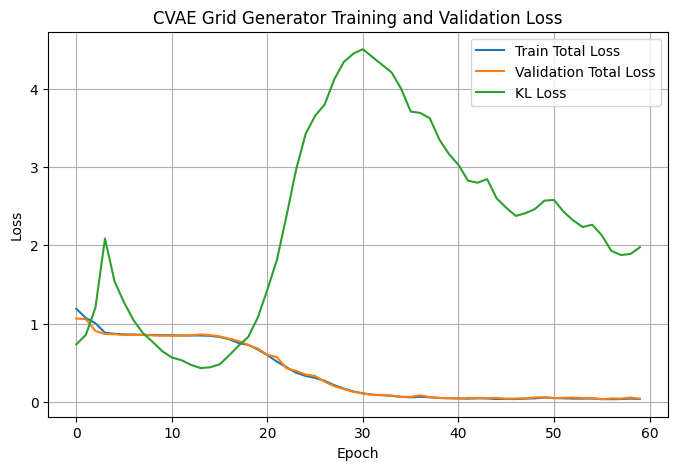

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(cvae_grid_train_losses, label="Train Total Loss")
plt.plot(cvae_grid_val_losses, label="Validation Total Loss")
plt.plot(cvae_grid_kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CVAE Grid Generator Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [59]:
cvae_grid_model.load_state_dict(
    torch.load(best_cvae_grid_path, map_location=DEVICE)
)
cvae_grid_model.eval()

cvae_eval_model = CVAEGridEvalWrapper(
    cvae_grid_model,
    use_mean=True
).to(DEVICE)

print("CVAE Grid Generation Test Quality:")
cvae_grid_quality = evaluate_grid_generation(
    cvae_eval_model,
    test_conditions,
    n_samples=300
)

for key, value in cvae_grid_quality.items():
    print(f"{key}: {value:.4f}")

print("\nSample CVAE Grid predictions:")
show_grid_predictions(cvae_eval_model, test_conditions, n=10)

CVAE Grid Generation Test Quality:
valid_format: 1.0000
day_match: 0.9800
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 0.9800

Sample CVAE Grid predictions:
Conditions: [WED] [JUN] [False] [219]
Predicted date: 29-6-2191
Some valid examples: ['2-6-2190', '9-6-2190', '16-6-2190', '23-6-2190', '30-6-2190']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [THU] [JAN] [False] [188]
Predicted date: 24-1-1889
Some valid examples: ['6-1-1881', '13-1-1881', '20-1-1881', '27-1-1881', '5-1-1882']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [SAT] [FEB] [False] [191]
Predicted date: 19-2-1910
Some valid examples: ['5-2-1910', '12-2-1910', '19-2-1910', '26-2-1910', '4-2-1911']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [MON] [FEB] [False] [215]
Predicted date: 8-2-2151
Some valid examples: ['2-2-2150

# Model 4 : MLP

In [66]:
class MLPGridGenerator(nn.Module):
    def __init__(
        self,
        d_model: int = 32,
        hidden_dim: int = 256,
        grid_size: int = GRID_SIZE,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])

        x = torch.cat([weekday, month, leap, decade], dim=1)
        return x

    def forward(self, condition_features):
        x = self.embed_conditions(condition_features)
        logits = self.net(x)
        return logits

In [67]:
mlp_grid_model = MLPGridGenerator(
    d_model=32,
    hidden_dim=256,
    grid_size=GRID_SIZE,
    dropout=0.1,
).to(DEVICE)

mlp_grid_optimizer = torch.optim.AdamW(
    mlp_grid_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

MLP_GRID_EPOCHS = 60

mlp_grid_train_losses = []
mlp_grid_val_losses = []

best_mlp_grid_val_loss = float("inf")
best_mlp_grid_path = f"{SAVE_DIR}/weights/mlp_grid_generator.pt"

for epoch in range(1, MLP_GRID_EPOCHS + 1):
    train_loss = train_grid_one_epoch(
        mlp_grid_model,
        grid_train_loader,
        mlp_grid_optimizer,
        grid_criterion
    )

    val_loss = evaluate_grid_loss(
        mlp_grid_model,
        grid_val_loader,
        grid_criterion
    )

    mlp_grid_train_losses.append(train_loss)
    mlp_grid_val_losses.append(val_loss)

    if val_loss < best_mlp_grid_val_loss:
        best_mlp_grid_val_loss = val_loss
        torch.save(mlp_grid_model.state_dict(), best_mlp_grid_path)

    if epoch % 5 == 0 or epoch == 1:
        quality = evaluate_grid_generation(
            mlp_grid_model,
            val_conditions,
            n_samples=300
        )

        print(
            f"Epoch [{epoch}/{MLP_GRID_EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Generation All Match: {quality['all_match']:.4f}"
        )

print("Best MLP Grid model saved to:", best_mlp_grid_path)

Epoch [1/60] Train Loss: 1.1493 | Val Loss: 1.0663 | Generation All Match: 0.0933
Epoch [5/60] Train Loss: 0.8701 | Val Loss: 0.8555 | Generation All Match: 0.1267
Epoch [10/60] Train Loss: 0.8520 | Val Loss: 0.8498 | Generation All Match: 0.1433
Epoch [15/60] Train Loss: 0.8482 | Val Loss: 0.8438 | Generation All Match: 0.1367
Epoch [20/60] Train Loss: 0.8296 | Val Loss: 0.8219 | Generation All Match: 0.1600
Epoch [25/60] Train Loss: 0.3833 | Val Loss: 0.2767 | Generation All Match: 0.6967
Epoch [30/60] Train Loss: 0.1133 | Val Loss: 0.0667 | Generation All Match: 0.9433
Epoch [35/60] Train Loss: 0.0742 | Val Loss: 0.0379 | Generation All Match: 0.9500
Epoch [40/60] Train Loss: 0.0442 | Val Loss: 0.0238 | Generation All Match: 0.9767
Epoch [45/60] Train Loss: 0.0405 | Val Loss: 0.0192 | Generation All Match: 0.9767
Epoch [50/60] Train Loss: 0.0345 | Val Loss: 0.0158 | Generation All Match: 0.9933
Epoch [55/60] Train Loss: 0.0248 | Val Loss: 0.0136 | Generation All Match: 0.9867
Epoch 

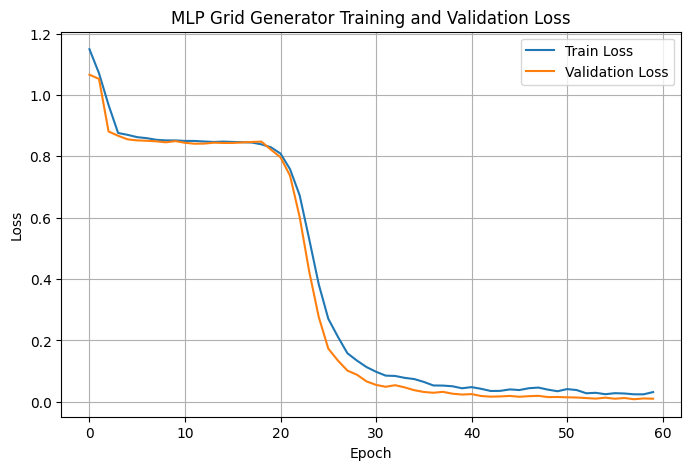

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_grid_train_losses, label="Train Loss")
plt.plot(mlp_grid_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Grid Generator Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
mlp_grid_model.load_state_dict(
    torch.load(best_mlp_grid_path, map_location=DEVICE)
)
mlp_grid_model.eval()

print("MLP Grid Generation Test Quality:")
mlp_grid_quality = evaluate_grid_generation(
    mlp_grid_model,
    test_conditions,
    n_samples=300
)

for key, value in mlp_grid_quality.items():
    print(f"{key}: {value:.4f}")

print("\nSample MLP Grid predictions:")
show_grid_predictions(mlp_grid_model, test_conditions, n=10)

MLP Grid Generation Test Quality:
valid_format: 1.0000
day_match: 1.0000
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 1.0000

Sample MLP Grid predictions:
Conditions: [SAT] [OCT] [False] [192]
Predicted date: 5-10-1929
Some valid examples: ['1-10-1921', '8-10-1921', '15-10-1921', '22-10-1921', '29-10-1921']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [SUN] [SEP] [False] [212]
Predicted date: 28-9-2121
Some valid examples: ['7-9-2121', '14-9-2121', '21-9-2121', '28-9-2121', '6-9-2122']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [MON] [DEC] [False] [202]
Predicted date: 18-12-2023
Some valid examples: ['6-12-2021', '13-12-2021', '20-12-2021', '27-12-2021', '5-12-2022']
All conditions satisfied: True
------------------------------------------------------------
Conditions: [TUE] [OCT] [False] [206]
Predicted date: 27-10-2065
Some valid examples:

In [70]:
import os
import shutil
from pathlib import Path

In [71]:
REPO_DIR = f"{SAVE_DIR}/repo"
MODEL_DIR = f"{REPO_DIR}/model"
WEIGHTS_DIR = f"{MODEL_DIR}/weights"
DATA_DIR = f"{REPO_DIR}/data"

In [72]:
os.makedirs(REPO_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)


In [73]:
shutil.copy(Data_Path, f"{DATA_DIR}/data.txt")
shutil.copy(Example_Path, f"{DATA_DIR}/example_input.txt")

print("Repo created at:", REPO_DIR)
print("Data copied.")

Repo created at: /content/drive/MyDrive/dates_generator/repo
Data copied.


In [74]:
weights_to_copy = {
    "ae_grid_generator.pt": f"{SAVE_DIR}/weights/ae_grid_generator.pt",
    "gan_grid_generator.pt": f"{SAVE_DIR}/weights/gan_grid_generator.pt",
    "cvae_grid_generator.pt": f"{SAVE_DIR}/weights/cvae_grid_generator.pt",
    "mlp_grid_generator.pt": f"{SAVE_DIR}/weights/mlp_grid_generator.pt",
}

for filename, src_path in weights_to_copy.items():
    dst_path = f"{WEIGHTS_DIR}/{filename}"

    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print("Copied:", filename)
    else:
        print("Missing, skipped:", filename)

Copied: ae_grid_generator.pt
Copied: gan_grid_generator.pt
Copied: cvae_grid_generator.pt
Copied: mlp_grid_generator.pt


In [75]:
utils_code = r'''
import re
import datetime
from typing import List, Dict

MONTH_TO_NUM = {
    "[JAN]": 1, "[FEB]": 2, "[MAR]": 3, "[APR]": 4,
    "[MAY]": 5, "[JUN]": 6, "[JUL]": 7, "[AUG]": 8,
    "[SEP]": 9, "[OCT]": 10, "[NOV]": 11, "[DEC]": 12,
}

DAY_TO_NUM = {
    "[MON]": 0, "[TUE]": 1, "[WED]": 2, "[THU]": 3,
    "[FRI]": 4, "[SAT]": 5, "[SUN]": 6,
}

REQ_WEEKDAY_SIZE = 7
REQ_MONTH_SIZE = 12
REQ_LEAP_SIZE = 2
REQ_DECADE_SIZE = 41

GRID_YEARS = 10
GRID_DAYS = 31
GRID_SIZE = GRID_YEARS * GRID_DAYS


def parse_input_line(line: str) -> List[str]:
    return line.strip().split()[:4]


def read_input_file(path: str) -> List[List[str]]:
    with open(path, "r", encoding="utf-8") as f:
        return [parse_input_line(line) for line in f.readlines() if line.strip()]


def condition_tokens_to_feature_ids(condition_tokens: List[str]) -> List[int]:
    day_cond, month_cond, leap_cond, decade_cond = condition_tokens

    required_weekday = DAY_TO_NUM[day_cond]
    required_month = MONTH_TO_NUM[month_cond] - 1
    required_leap = 1 if leap_cond == "[True]" else 0

    decade_prefix = int(decade_cond.replace("[", "").replace("]", ""))
    required_decade = decade_prefix - 180

    return [required_weekday, required_month, required_leap, required_decade]


def is_leap_year(year: int) -> bool:
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)


def parse_generated_date(date_str: str):
    match = re.fullmatch(r"\d{1,2}-\d{1,2}-\d{4}", date_str)
    if match is None:
        return None

    try:
        d, m, y = map(int, date_str.split("-"))
        return datetime.date(y, m, d)
    except Exception:
        return None


def validate_date_against_conditions(date_str: str, conditions: List[str]) -> Dict[str, bool]:
    result = {
        "valid_format": False,
        "day_match": False,
        "month_match": False,
        "leap_match": False,
        "decade_match": False,
        "all_match": False,
    }

    dt = parse_generated_date(date_str)
    if dt is None:
        return result

    result["valid_format"] = True

    day_cond, month_cond, leap_cond, decade_cond = conditions

    result["day_match"] = dt.weekday() == DAY_TO_NUM[day_cond]
    result["month_match"] = dt.month == MONTH_TO_NUM[month_cond]

    expected_leap = True if leap_cond == "[True]" else False
    result["leap_match"] = is_leap_year(dt.year) == expected_leap

    decade_prefix = int(decade_cond.replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10
    end_year = start_year + 9

    result["decade_match"] = start_year <= dt.year <= end_year

    result["all_match"] = (
        result["valid_format"]
        and result["day_match"]
        and result["month_match"]
        and result["leap_match"]
        and result["decade_match"]
    )

    return result


def index_to_year_offset_day(index: int):
    year_offset = index // GRID_DAYS
    day = (index % GRID_DAYS) + 1
    return year_offset, day


def decode_grid_prediction(logits, condition_tokens: List[str]) -> str:
    import torch

    scores = logits.detach().cpu()
    sorted_indices = torch.argsort(scores, descending=True).tolist()

    month = MONTH_TO_NUM[condition_tokens[1]]

    decade_prefix = int(condition_tokens[3].replace("[", "").replace("]", ""))
    start_year = decade_prefix * 10

    for idx in sorted_indices:
        year_offset, day = index_to_year_offset_day(idx)
        year = start_year + year_offset

        try:
            datetime.date(year, month, day)
            return f"{day}-{month}-{year}"
        except ValueError:
            continue

    return "1-1-1800"
'''

with open(f"{MODEL_DIR}/utils.py", "w", encoding="utf-8") as f:
    f.write(utils_code)

print("Created model/utils.py")

Created model/utils.py


In [76]:
models_code = r'''
import torch
import torch.nn as nn

from utils import (
    REQ_WEEKDAY_SIZE,
    REQ_MONTH_SIZE,
    REQ_LEAP_SIZE,
    REQ_DECADE_SIZE,
    GRID_SIZE,
)


class AEGridGenerator(nn.Module):
    def __init__(self, d_model=32, hidden_dim=128, latent_dim=64, grid_size=GRID_SIZE):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])
        return torch.cat([weekday, month, leap, decade], dim=1)

    def forward(self, condition_features):
        x = self.embed_conditions(condition_features)
        z = self.encoder(x)
        return self.decoder(z)


class GANGridGenerator(nn.Module):
    def __init__(self, noise_dim=32, d_model=32, hidden_dim=128, grid_size=GRID_SIZE):
        super().__init__()

        self.noise_dim = noise_dim

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model + noise_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])
        return torch.cat([weekday, month, leap, decade], dim=1)

    def forward(self, condition_features):
        batch_size = condition_features.size(0)
        device = condition_features.device
        noise = torch.randn(batch_size, self.noise_dim, device=device)

        cond_emb = self.embed_conditions(condition_features)
        x = torch.cat([cond_emb, noise], dim=1)
        return self.net(x)


class CVAEGridGenerator(nn.Module):
    def __init__(self, d_model=32, hidden_dim=128, latent_dim=64, grid_size=GRID_SIZE):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])
        return torch.cat([weekday, month, leap, decade], dim=1)

    def encode(self, condition_features):
        cond_emb = self.embed_conditions(condition_features)
        h = self.encoder(cond_emb)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar, cond_emb

    def forward(self, condition_features):
        mu, logvar, cond_emb = self.encode(condition_features)
        z = mu
        decoder_input = torch.cat([z, cond_emb], dim=1)
        return self.decoder(decoder_input)


class MLPGridGenerator(nn.Module):
    def __init__(self, d_model=32, hidden_dim=256, grid_size=GRID_SIZE, dropout=0.1):
        super().__init__()

        self.weekday_embedding = nn.Embedding(REQ_WEEKDAY_SIZE, d_model)
        self.month_embedding = nn.Embedding(REQ_MONTH_SIZE, d_model)
        self.leap_embedding = nn.Embedding(REQ_LEAP_SIZE, d_model)
        self.decade_embedding = nn.Embedding(REQ_DECADE_SIZE, d_model)

        input_dim = 4 * d_model

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, grid_size),
        )

    def embed_conditions(self, condition_features):
        weekday = self.weekday_embedding(condition_features[:, 0])
        month = self.month_embedding(condition_features[:, 1])
        leap = self.leap_embedding(condition_features[:, 2])
        decade = self.decade_embedding(condition_features[:, 3])
        return torch.cat([weekday, month, leap, decade], dim=1)

    def forward(self, condition_features):
        x = self.embed_conditions(condition_features)
        return self.net(x)


def build_model(model_name: str):
    if model_name == "ae":
        return AEGridGenerator()

    if model_name == "gan":
        return GANGridGenerator()

    if model_name == "cvae":
        return CVAEGridGenerator()

    if model_name == "mlp":
        return MLPGridGenerator()

    raise ValueError(f"Unknown model name: {model_name}")
'''

with open(f"{MODEL_DIR}/models.py", "w", encoding="utf-8") as f:
    f.write(models_code)

print("Created model/models.py")

Created model/models.py


In [77]:
predict_code = r'''
import argparse
import os
import torch

from utils import (
    read_input_file,
    condition_tokens_to_feature_ids,
    decode_grid_prediction,
)

from models import build_model


DEFAULT_MODEL = "mlp"

WEIGHT_FILES = {
    "ae": "ae_grid_generator.pt",
    "gan": "gan_grid_generator.pt",
    "cvae": "cvae_grid_generator.pt",
    "mlp": "mlp_grid_generator.pt",
}


def load_model(model_name: str, device):
    model = build_model(model_name)

    current_dir = os.path.dirname(os.path.abspath(__file__))
    weights_path = os.path.join(current_dir, "weights", WEIGHT_FILES[model_name])

    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Missing weights file: {weights_path}")

    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model


def predict_file(input_path: str, output_path: str, model_name: str = DEFAULT_MODEL):
    torch.manual_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = load_model(model_name, device)

    condition_lines = read_input_file(input_path)

    outputs = []

    with torch.no_grad():
        for cond_tokens in condition_lines:
            features = torch.tensor(
                [condition_tokens_to_feature_ids(cond_tokens)],
                dtype=torch.long,
                device=device
            )

            logits = model(features)[0]
            pred_date = decode_grid_prediction(logits, cond_tokens)

            output_line = " ".join(cond_tokens) + " " + pred_date
            outputs.append(output_line)

    with open(output_path, "w", encoding="utf-8") as f:
        for line in outputs:
            f.write(line + "\n")

    print(f"Saved predictions to: {output_path}")


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("-i", "--input", required=True)
    parser.add_argument("-o", "--output", required=True)
    parser.add_argument(
        "--model",
        default=DEFAULT_MODEL,
        choices=["ae", "gan", "cvae", "mlp"]
    )

    args = parser.parse_args()

    predict_file(
        input_path=args.input,
        output_path=args.output,
        model_name=args.model
    )


if __name__ == "__main__":
    main()
'''

with open(f"{MODEL_DIR}/predict.py", "w", encoding="utf-8") as f:
    f.write(predict_code)

print("Created model/predict.py")

Created model/predict.py


In [78]:
evaluate_code = r'''
import argparse
from utils import validate_date_against_conditions


def evaluate_predictions(prediction_file: str):
    lines = []

    with open(prediction_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                lines.append(line.strip())

    total = 0
    valid_format = 0
    day_match = 0
    month_match = 0
    leap_match = 0
    decade_match = 0
    all_match = 0

    for line in lines:
        parts = line.split()

        cond_tokens = parts[:4]
        pred_date = parts[4]

        result = validate_date_against_conditions(pred_date, cond_tokens)

        total += 1
        valid_format += int(result["valid_format"])
        day_match += int(result["day_match"])
        month_match += int(result["month_match"])
        leap_match += int(result["leap_match"])
        decade_match += int(result["decade_match"])
        all_match += int(result["all_match"])

    metrics = {
        "valid_format": valid_format / total,
        "day_match": day_match / total,
        "month_match": month_match / total,
        "leap_match": leap_match / total,
        "decade_match": decade_match / total,
        "all_match": all_match / total,
    }

    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("-p", "--predictions", required=True)
    args = parser.parse_args()

    evaluate_predictions(args.predictions)


if __name__ == "__main__":
    main()
'''

with open(f"{MODEL_DIR}/evaluate.py", "w", encoding="utf-8") as f:
    f.write(evaluate_code)

print("Created model/evaluate.py")

Created model/evaluate.py


In [79]:
train_code = r'''
"""
Training code summary.

The submitted notebook contains the full training pipeline for:
1. AE Grid Generator
2. GAN Grid Generator
3. CVAE Grid Generator
4. MLP Grid Generator

All models use the same formulation:

conditions -> 310 grid logits

where:
310 = 10 years in the required decade × 31 possible days.

Trained weights are stored under:
model/weights/

Inference:
python predict.py -i ../data/example_input.txt -o ../predictions.txt
"""

if __name__ == "__main__":
    print("Full training is provided in the submitted notebook.")
    print("Use predict.py for inference.")
'''

with open(f"{MODEL_DIR}/train.py", "w", encoding="utf-8") as f:
    f.write(train_code)

print("Created model/train.py")

Created model/train.py


In [80]:
environment_code = r'''
name: dates-generator
channels:
  - pytorch
  - conda-forge
  - defaults

dependencies:
  - python=3.10
  - pip
  - numpy
  - pandas
  - matplotlib
  - pytorch
  - cpuonly
'''

with open(f"{REPO_DIR}/environment.yml", "w", encoding="utf-8") as f:
    f.write(environment_code)

print("Created environment.yml")

Created environment.yml


In [81]:
test_output_path = f"{REPO_DIR}/predictions.txt"

cmd = f"""
cd {MODEL_DIR}
python predict.py -i ../data/example_input.txt -o ../predictions.txt
"""

print(cmd)
os.system(cmd)

print("\nFirst 10 prediction lines:")
with open(test_output_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())


cd /content/drive/MyDrive/dates_generator/repo/model
python predict.py -i ../data/example_input.txt -o ../predictions.txt


First 10 prediction lines:
[WED] [JAN] [False] [180] 28-1-1801
[MON] [JAN] [False] [190] 28-1-1901
[SAT] [JAN] [True] [200] 29-1-2000
[FRI] [JAN] [False] [210] 28-1-2101
[WED] [JAN] [False] [220] 28-1-2201
[WED] [FEB] [False] [189] 6-2-1895
[MON] [FEB] [False] [199] 20-2-1995
[SUN] [FEB] [False] [209] 6-2-2095
[FRI] [FEB] [False] [219] 6-2-2195
[TUE] [MAR] [False] [189] 24-3-1891


In [82]:
cmd = f"""
cd {MODEL_DIR}
python evaluate.py -p ../predictions.txt
"""

print(cmd)
os.system(cmd)


cd /content/drive/MyDrive/dates_generator/repo/model
python evaluate.py -p ../predictions.txt



0

In [83]:

import subprocess

cmd = [
    "python",
    f"{MODEL_DIR}/evaluate.py",
    "-p",
    f"{REPO_DIR}/predictions.txt"
]

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

Return code: 0
STDOUT:
valid_format: 1.0000
day_match: 0.9966
month_match: 1.0000
leap_match: 1.0000
decade_match: 1.0000
all_match: 0.9966

STDERR:



In [2]:
SAVE_DIR = "/content/drive/MyDrive/dates_generator"

REPO_DIR = f"{SAVE_DIR}/repo"
MODEL_DIR = f"{REPO_DIR}/model"
WEIGHTS_DIR = f"{MODEL_DIR}/weights"
DATA_DIR = f"{REPO_DIR}/data"

print("REPO_DIR:", REPO_DIR)

REPO_DIR: /content/drive/MyDrive/dates_generator/repo


In [5]:
input_path = f"{REPO_DIR}/data/example_input.txt"
output_path = f"{REPO_DIR}/predictions.txt"

with open(input_path, "r", encoding="utf-8") as f:
    input_lines = [line.strip() for line in f if line.strip()]

with open(output_path, "r", encoding="utf-8") as f:
    output_lines = [line.strip() for line in f if line.strip()]

print("Input lines:", len(input_lines))
print("Output lines:", len(output_lines))
print("Same count:", len(input_lines) == len(output_lines))

print("\nFirst input:")
print(input_lines[0])

print("\nFirst output:")
print(output_lines[0])

Input lines: 1465
Output lines: 1465
Same count: True

First input:
[WED] [JAN] [False] [180]

First output:
[WED] [JAN] [False] [180] 28-1-1801
